In [16]:
# convert .json to pd.dataframe
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# UDFs functions
from src.functions import create_stocks_dataframe
from src.prepare_data import prepare_stock_data
from src.yearwise_price_change_summary import get_historical_prices
from src.return_calculate import calculate_returns
from src.price_status import calculate_price_status
from src.duck_db_utils import get_db_table_names, get_conn, close_conn, get_table_data

In [17]:
from src.load_config import load_json_config
local_config = load_json_config("config/local.json")
local_config["database_path"]

'C:/Users/rocke/OneDrive/1. daily_deliverables/1. master_folder/investment_strategy/project_automation/stock_db/src/data/stocks.duckdb'

In [18]:
conn = get_conn()
conn.execute("SELECT * FROM stocks LIMIT 5").fetchall()

[(1, 'TCPLPACK', 'NSE', datetime.datetime(2026, 8, 12, 22, 51, 37, 229000)),
 (2, 'ABBOTINDIA', 'NSE', datetime.datetime(2026, 8, 12, 22, 56, 59, 597000)),
 (4, 'ASTRAZEN', 'NSE', datetime.datetime(2026, 8, 12, 22, 57, 9, 598000)),
 (5, 'SUPREMEIND', 'NSE', datetime.datetime(2026, 8, 12, 22, 57, 15, 273000)),
 (6, 'HAL', 'NSE', datetime.datetime(2026, 8, 12, 22, 57, 22, 344000))]

In [19]:
close_conn()
conn = get_conn()
get_db_table_names(conn)

['refresh_log', 'stock_data', 'stocks', 'tbl_priority', 'todays_data']

In [20]:
import importlib
import src.duck_db_utils as duck_db_utils
importlib.reload(duck_db_utils) #force Python to reload a module's code without restarting the Python interpreter or Jupyter kernel.
from src.duck_db_utils import get_table_data

In [21]:
stocks_schema = get_table_data(conn, "stocks")
stocks_schema

,id,symbol,exchange,created_at
0,1,TCPLPACK,NSE,2026-08-12 22:51:37.229
1,2,ABBOTINDIA,NSE,2026-08-12 22:56:59.597
2,4,ASTRAZEN,NSE,2026-08-12 22:57:09.598
3,5,SUPREMEIND,NSE,2026-08-12 22:57:15.273
4,6,HAL,NSE,2026-08-12 22:57:22.344
5,7,TRENT,NSE,2026-08-12 22:57:31.688
6,8,MAZDOCK,NSE,2026-08-12 22:57:37.798
7,9,RELIANCE,NSE,2026-08-12 22:57:43.206
8,10,LLOYDSENGG,NSE,2026-08-12 22:57:47.662
9,11,SAPPHIRE,NSE,2026-08-12 22:57:53.859


In [22]:
stock_data = get_table_data(conn, "stock_data")
stock_data.head(2)

,stock_name,stock_id,exchange,symbol,trade_date,open,high,low,close,adj_close,volume,created_at
0,TCPL Packaging Limited,1,NSE,TCPLPACK,2026-01-01,3015.899902,3059.000000,3002.100098,3041.399902,3018.010254,650,2026-08-16 21:47:42.086
1,TCPL Packaging Limited,1,NSE,TCPLPACK,2026-01-02,3036.800049,3052.800049,2999.500000,3006.000000,2982.882568,1687,2026-08-16 21:47:42.092


In [23]:
uq_stock_names = stock_data["symbol"].unique()
uq_stock_names

<StringArray>
[  'TCPLPACK', 'ABBOTINDIA',   'ASTRAZEN',      'DIXON',        'HAL',
 'LLOYDSENGG',    'MAZDOCK',   'RELIANCE',   'SAPPHIRE', 'SUPREMEIND',
   'TAALTECH',      'TRENT',     '523323']
Length: 13, dtype: str

# Individual stock analysis example

In [24]:
# Individual stock analysis example
symbol_name = "RELIANCE"
stock_data = get_table_data(conn, "stock_data")
stock_data_symbol = stock_data[stock_data["symbol"] == symbol_name]


In [25]:
todays_data = get_table_data(conn, "todays_data")
todays_data[todays_data["symbol"] == symbol_name]

,stock_id,stock_name,exchange,symbol,quote_date,open,high,low,close,adj_close,...,pe_ratio_trailing,pe_ratio_forward,beta_5y_monthly,market_cap,fifty_two_week_high,fifty_two_week_low,company_name,sector,industry,fetched_at
8,9,Reliance Industries Limited,NSE,RELIANCE,2026-08-14,1317.0,1317.5,1301.5,1310.0,1310.0,...,23.69754,18.31015,0.157,1.772754e+13,1611.8,1249.8,Reliance Industries Limited,Energy,Oil & Gas Refining & Marketing,2026-08-16 17:55:07.484


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pandas as pd

def create_stock_forecast_chart(stock_data, todays_data, symbol_name):
    """
    Create an enhanced stock price forecast chart with multiple analytical insights.
    Automatically handles data sorting and NaN values.
    """
    
    # Create a clean copy
    clean_data = stock_data[['trade_date', 'adj_close']].copy()
    
    # Sort by date (oldest to newest) - CRITICAL FIX
    clean_data = clean_data.sort_values('trade_date', ascending=True).reset_index(drop=True)
    
    # Remove any NaN values
    clean_data = clean_data.dropna(subset=['adj_close', 'trade_date'])
    
    if len(clean_data) == 0:
        print("❌ Error: No valid data available after cleaning")
        return None, None, None
    
    print(f"✅ Data cleaned: {len(clean_data)} valid data points")
    print(f"📅 Date range: {clean_data['trade_date'].iloc[0].strftime('%Y-%m-%d')} to {clean_data['trade_date'].iloc[-1].strftime('%Y-%m-%d')}")
    
    # Prepare data for regression
    x = np.arange(len(clean_data))
    y = clean_data['adj_close'].values
    
    # Fit linear regression
    coefficients = np.polyfit(x, y, 1)
    linear_fit = np.poly1d(coefficients)
    forecast_line = linear_fit(x)
    
    # Calculate R-squared and RMSE manually
    y_mean = np.mean(y)
    ss_tot = np.sum((y - y_mean) ** 2)
    ss_res = np.sum((y - forecast_line) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    rmse = np.sqrt(ss_res / len(y))
    
    # Get current price
    current_price = np.nan
    if not todays_data.empty and 'symbol' in todays_data.columns and 'current_price' in todays_data.columns:
        cp = todays_data.loc[todays_data['symbol'] == symbol_name, 'current_price']
        if not cp.empty:
            try:
                current_price = float(cp.iloc[0])
            except (ValueError, TypeError):
                current_price = np.nan
    
    # Calculate forecasted future prices (next 5 trading days)
    future_days = 180
    future_x = np.arange(len(clean_data), len(clean_data) + future_days)
    future_prices = linear_fit(future_x)
    
    # Generate future dates (assuming trading days)
    last_date = clean_data['trade_date'].iloc[-1]
    future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=future_days, freq='B')
    
    # Calculate trend metrics
    daily_change = coefficients[0]  # Slope
    annualized_change = daily_change * 252
    trend_direction = "📈 UPWARD" if daily_change > 0 else "📉 DOWNWARD"
    
    # Determine trend strength
    price_range = np.max(y) - np.min(y)
    trend_strength = "Strong" if abs(daily_change) > (0.1 * price_range / len(y)) else "Moderate"
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [3, 1]})
    
    # Main plot (left)
    ax1.plot(clean_data['trade_date'], clean_data['adj_close'], 
             marker='o', linewidth=2, markersize=3, 
             label='Historical Price', color='#2E86AB', alpha=0.7)
    
    # Historical forecast line
    ax1.plot(clean_data['trade_date'], forecast_line, 
             color='#D64933', linestyle='--', linewidth=2, 
             label=f'Linear Trend (R²={r2:.3f})')
    
    # Future forecast
    ax1.plot(future_dates, future_prices, 
             color='#D64933', linestyle='-', linewidth=2.5, 
             marker='s', markersize=6, label='Forecast Period')
    
    # Confidence interval
    prediction_std = np.std(y - forecast_line)
    ax1.fill_between(future_dates, 
                     future_prices - 1.96 * prediction_std, 
                     future_prices + 1.96 * prediction_std, 
                     alpha=0.2, color='#D64933', label='95% Confidence Interval')
    
    # Current price marker
    if not np.isnan(current_price):
        # Find the most recent date in data
        most_recent_date = clean_data['trade_date'].iloc[-1]
        
        ax1.scatter([most_recent_date], [current_price], 
                   color='#2ECC71', s=200, marker='D', 
                   zorder=5, edgecolor='white', linewidth=2,
                   label=f'Current Price: ₹{current_price:,.2f}')
        
        # Add horizontal line
        ax1.axhline(current_price, color='#2ECC71', 
                   linestyle=':', alpha=0.5, linewidth=1.5)
        
        # Annotation
        ax1.annotate(f'₹{current_price:,.2f}', 
                    xy=(most_recent_date, current_price),
                    xytext=(15, 15), 
                    textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.3),
                    fontweight='bold', fontsize=10,
                    arrowprops=dict(arrowstyle='->', color='#2ECC71', lw=1.5))
    
    # Highlight forecast zone
    ax1.axvspan(clean_data['trade_date'].iloc[-1], future_dates[-1], 
                alpha=0.1, color='#D64933', label='Forecast Zone')
    
    # Formatting
    ax1.set_xlabel('Trade Date', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Adjusted Closing Price (₹)', fontsize=11, fontweight='bold')
    ax1.set_title(f'{symbol_name} - Price Trend with Linear Forecast\n({len(clean_data)} days of data)', 
                 fontsize=14, fontweight='bold', pad=15)
    ax1.legend(loc='upper left', framealpha=0.9, fontsize=9)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add statistical insights (right side)
    ax2.axis('off')
    
    start_date = clean_data['trade_date'].iloc[0].strftime('%b %d, %Y')
    end_date = clean_data['trade_date'].iloc[-1].strftime('%b %d, %Y')
    
    # Calculate price change
    price_change = clean_data['adj_close'].iloc[-1] - clean_data['adj_close'].iloc[0]
    price_change_pct = (price_change / clean_data['adj_close'].iloc[0]) * 100
    
    insights_text = f"""
    📊 PRICE INSIGHTS
    ─────────────────────────
    
    ⏱️ Analysis Period
    {start_date} - {end_date}
    Days: {len(clean_data)}
    
    📈 Trend Analysis
    • Direction: {trend_direction}
    • Strength: {trend_strength}
    • Daily Change: ₹{daily_change:.2f}
    
    📊 Performance
    • Start Price: ₹{clean_data['adj_close'].iloc[0]:,.2f}
    • End Price: ₹{clean_data['adj_close'].iloc[-1]:,.2f}
    • Total Change: {price_change_pct:+.2f}%
    
    📊 Model Quality
    • R-Squared: {r2:.3f}
    • RMSE: ₹{rmse:.2f}
    
    🔮 Forecast (Next {future_days} Days)
    • Start: ₹{future_prices[0]:,.2f}
    • End: ₹{future_prices[-1]:,.2f}
    • Change: ₹{future_prices[-1] - future_prices[0]:,.2f}
    """
    
    if not np.isnan(current_price):
        insights_text += f"""
    
    💰 Current Price: ₹{current_price:,.2f}
    {'🟢' if future_prices[-1] > current_price else '🔴'} 
    Expected Trend: {'Upside' if future_prices[-1] > current_price else 'Downside'}
    Expected {'GAIN' if future_prices[-1] > current_price else 'LOSS'}: ₹{abs(future_prices[-1] - current_price):,.2f}
    """
    
    insights_text += """
    
    ⚠️ Note: Simplified linear model.
    Past ≠ Future performance.
    """
    
    ax2.text(0.1, 0.5, insights_text, 
            transform=ax2.transAxes,
            fontsize=10, verticalalignment='center',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#F8F9FA', 
                     edgecolor='#343A40', alpha=0.9),
            family='monospace')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n{'='*65}")
    print(f"📈 {symbol_name} - Forecast Summary")
    print(f"{'='*65}")
    print(f"Data Period: {start_date} to {end_date}")
    print(f"Data Points: {len(clean_data)}")
    print(f"Price Change: {price_change_pct:+.2f}% (₹{price_change:+,.2f})")
    if not np.isnan(current_price):
        print(f"Current Price: ₹{current_price:,.2f}")
    print(f"Next {future_days} days forecast: ₹{future_prices[-1]:,.2f}")
    if not np.isnan(current_price):
        print(f"Expected {'GAIN' if future_prices[-1] > current_price else 'LOSS'}: ₹{abs(future_prices[-1] - current_price):,.2f}")
    print(f"Model R²: {r2:.3f} ({'Good' if r2 > 0.7 else 'Moderate' if r2 > 0.4 else 'Poor'})")
    print(f"{'='*65}\n")
    
    return future_prices, r2, rmse

# Now run the function
# future_prices, r2, rmse = create_stock_forecast_chart(stock_data_symbol, todays_data, symbol_name)

✅ Data cleaned: 2626 valid data points
📅 Date range: 2016-01-01 to 2026-08-14


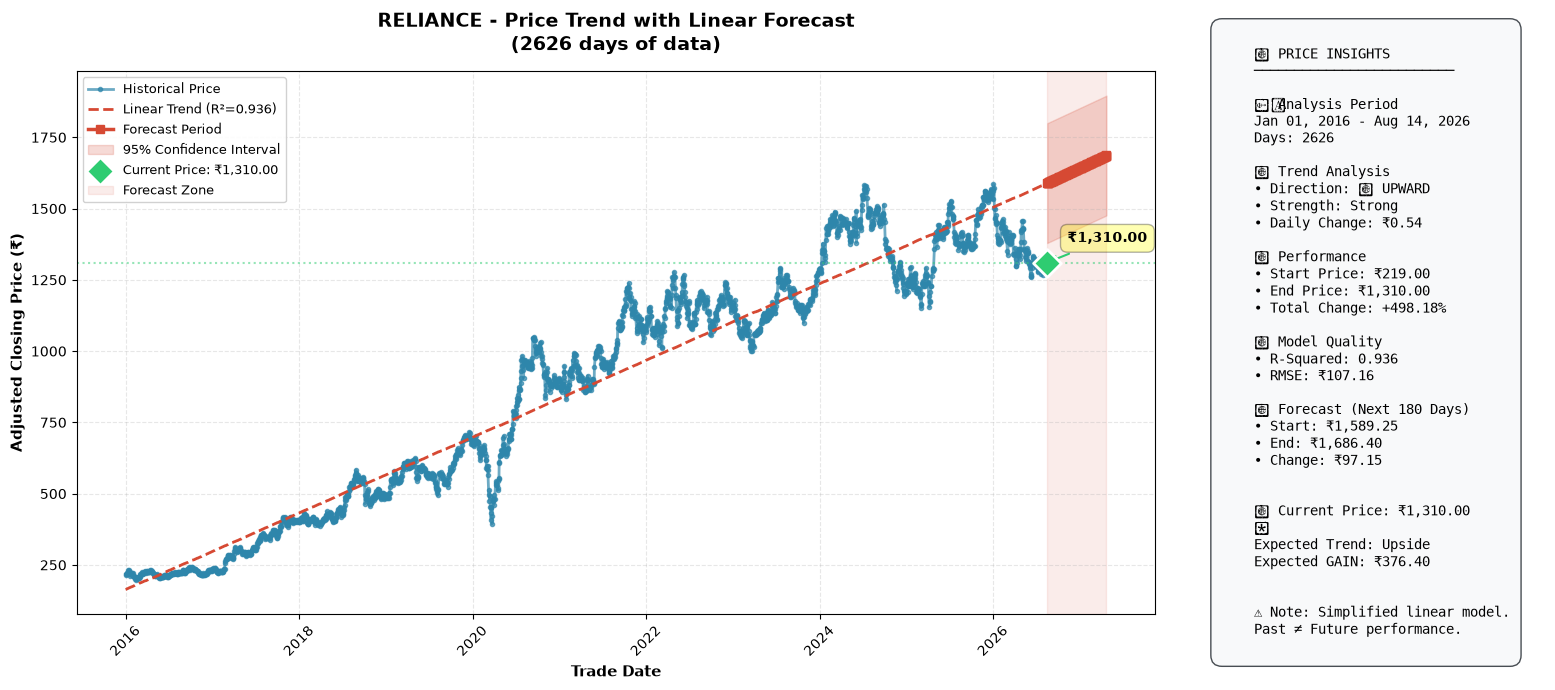


📈 RELIANCE - Forecast Summary
Data Period: Jan 01, 2016 to Aug 14, 2026
Data Points: 2626
Price Change: +498.18% (₹+1,091.00)
Current Price: ₹1,310.00
Next 180 days forecast: ₹1,686.40
Expected GAIN: ₹376.40
Model R²: 0.936 (Good)



In [27]:
# Then run the chart:
future_prices, r2, rmse = create_stock_forecast_chart(stock_data_symbol, todays_data, symbol_name)

In [28]:
# Determine forecast direction
# get_direction = "up" if coefficients[0] > 0 else "down"
# print(f"The forecasted trend for {symbol_name} is: {get_direction}")

In [29]:
# current_price = stock_data['adj_close'].iloc[-1]
# forecasted_price = forecast_line[-1]

In [30]:
# print(current_price, forecasted_price)

In [31]:

# get_trend = calculate_price_status(current_price, forecasted_price, discount_threshold=1.1, precision=2)

In [32]:
# get_trend = "premium" if current_price > forecasted_price and current_price < 1.1 * forecasted_price else "at par" if current_price == forecasted_price else "discount"
# print(f"The current price is at a {get_trend} compared to the forecasted price.")

In [33]:
# # Filter data for Krishna Institute of Medical Sciences Limited
# result_df = price_df[price_df['stock_name'] == stock_name].copy()

# # Ensure date column is datetime type
# result_df['date'] = pd.to_datetime(result_df['date'])

# # Sort by date to ensure chronological order
# result_df = result_df.sort_values('date')

# # Create a DataFrame with date as index for easier lookup
# price_series = result_df.set_index('date')['closing_price']

# # Get today's date and the earliest date in your dataset
# today = datetime.now()
# earliest_date = result_df['date'].min()
# latest_date = result_df['date'].max()
# latest_price = result_df.iloc[-1]['closing_price']  # Get the latest price

# # Calculate how many years of data we have
# years_of_data = today.year - earliest_date.year

# # Create lists to store results - starting with latest date
# years_back_list = ['Latest']  # Start with 'Latest' for current price
# lookup_dates = [latest_date]
# closing_prices = [latest_price]
# target_dates_list = [today]
# days_differences = [0]


In [34]:
# data_dict = prepare_stock_data(
#     price_df=stock_data,
#     stock_name=stock_name,
#     date_col='trade_date',
#     price_col='adj_close',
#     name_col='stock_name')

In [35]:
# # Get prices for each year back until we run out of data
# for years_back in range(1, data_dict['years_of_data'] + 2):  # +2 to include partial years
#     # Calculate the target date (years back from today)
#     target_date = data_dict['today'] - timedelta(days=365 * years_back)
    
#     # Check if target date is before earliest date in dataset
#     if target_date < data_dict['earliest_date']:
#         print(f"\nStopping at {years_back-1} years back. Target date {target_date.date()} is before earliest data ({data_dict['earliest_date'].date()})")
#         break
    
#     # Find the closest available date and price
#     actual_date, price, days_diff = find_closest_date(target_date, data_dict['price_series'])
    
#     if actual_date is not None and price is not None:
#         data_dict['years_back_list'].append(years_back)
#         data_dict['target_dates_list'].append(target_date)
#         data_dict['lookup_dates'].append(actual_date)
#         data_dict['closing_prices'].append(price)
#         data_dict['days_differences'].append(days_diff)
#     else:
#         print(f"No data found for {years_back} years back ({target_date.date()})")

# # Create the result DataFrame
# if data_dict['years_back_list']:  # Check if we found any data
#     result_df = pd.DataFrame({
#         'Years Back': data_dict['years_back_list'],
#         'Target Date': data_dict['target_dates_list'],
#         'Actual Date': data_dict['lookup_dates'],
#         'Closing Price': data_dict['closing_prices'],
#         'Days Difference': data_dict['days_differences']
#     })
    
#     # Create simplified version with just Years Back, Actual Date, and Closing Price
#     simplified_df = result_df[['Years Back', 'Actual Date', 'Closing Price']].rename(
#         columns={'Actual Date': 'lookup_date', 'Closing Price': 'Closing price'}
#     )
    
    # print(f"\nLatest available data point: {data_dict['latest_date'].date()} - ₹{data_dict['latest_price']}")

In [36]:
# # Call the function
# result_df, simplified_df = get_historical_prices(data_dict)

# if result_df is not None:
#     print(f"Found {len(result_df)} years of historical prices")
#     print(simplified_df.head())

In [37]:
# print(simplified_df)

In [38]:
# Calculate the returns
# simplified_df = calculate_returns(simplified_df)

In [39]:
# print(simplified_df)

In [40]:
# Convert ROI(in pct) strings like '26%' or '-' to numeric floats (percent)
# roi_numeric = pd.to_numeric(
# 	simplified_df['ROI(in pct)'].astype(str).str.rstrip('%').replace({'-': np.nan, '': np.nan})
# )
# median_return = np.nanmedian(roi_numeric)
# print(f"\nMedian Return (in pct): {median_return}")
                           

In [41]:
# Add a new key-value pair
# stock_metadata = {
#     'symbol_name': symbol_name
# }
# stock_metadata['median_return'] = float(median_return)
# stock_metadata['current_return'] = float(simplified_df[simplified_df['Years Back']=='Latest']['ROI(in pct)'].values[0])
# stock_metadata['direction'] = get_direction()
# stock_metadata['trend'] = get_trend()

In [42]:
# stock_metadata